In [1]:
import pandas as pd
import lightgbm as lgb
from dataclasses import dataclass
from pathlib import Path
from matplotlib.axes import Axes
from matplotlib.dates import DateFormatter


from freeze_thaw.config import config as c, StationName
from freeze_thaw.data_preparation.splitting import get_test_set
from freeze_thaw.modeling.lgb_test import lgb_pred, TestResult
from freeze_thaw.evaluation.metrics import formatted_cm, calculate_f1_scores
from freeze_thaw.data_understanding.visualization import plot_with_labels

# LightGBM Model Trained on ASCAT Data vs ERA5

This notebook will determine if there's any difference in using a lightGBM model with default parameters trained on ASCAT data vs ERA5 in predicting the soil state at individual ISMN stations. The two methods will be evaluated on 20% of the data (most recent). First, confusion matrices will be compared between the two methods for each station. Then, a statistical analysis will be done to determine if there's a statistically significant difference in the two methods when it comes to the macro and transition F1 scores.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*
3. **Statistical Analysis**
4. **Conclusions**
---

## 1. Setup

### 1.1 Variables

In [2]:
result_df_ascat = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])
result_df_era5 = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])

label_map = {
    c.CLASSES[0]: 0,
    c.CLASSES[1]: 1,
    c.CLASSES[2]: 2,
}
train_size = 0.8

### 1.2 Functions

In [11]:
@dataclass(frozen=True)
class ERA5Results:
    macro_f1: float
    transition_f1: float
    y_pred: pd.Series

@dataclass(frozen=True)
class StationResults:
    y_true: pd.Series
    ismn_data: pd.DataFrame
    lgb_results: TestResult
    era5_results: ERA5Results

def process_one_station(station: StationName,
                        train_size: float,
                        label_map: dict[str, int],
                        model_dir: Path | None = None,
                        ismn_long_var_name: str | None = None) -> StationResults:
    """
    For the given station, load lgb model, predict on test set, and return model results and ERA5 predictions.
    :param station: name of the ISMN station
    :param train_size: decimal fraction size of training data
    :param label_map: mapping of class names to int labels
    :param model_dir: path to directory containing the models
    :param ismn_long_var_name: long name of the ISMN key variable
    :return: StationResults
    """
    model_dir = model_dir or c.MODEL_PATH
    ismn_long_var_name = ismn_long_var_name or c.ISMN_LONG_VAR_NAME

    ascat_test, era5_test = get_test_set(station, train_size=train_size, label_map=label_map)
    y_true = era5_test["class"]

    lgb_model = lgb.Booster(model_file=model_dir / f"{station}_model.txt")
    lgb_results = lgb_pred(ascat_test, lgb_model, label_map)

    era5_macro_f1, era5_transition_f1 = calculate_f1_scores(y_true, era5_test["pred"], list(label_map.keys()))

    era5_results = ERA5Results(macro_f1=era5_macro_f1,
                               transition_f1=era5_transition_f1,
                               y_pred=era5_test["pred"])

    ismn_data = era5_test.copy()
    ismn_data = ismn_data.drop(columns=[col for col in ismn_data.columns if col != ismn_long_var_name])

    return StationResults(y_true=y_true,
                          lgb_results=lgb_results,
                          era5_results=era5_results,
                          ismn_data=ismn_data)

def plot_predictions(df: pd.DataFrame,
                     station: StationName,
                     method: str,
                     *,
                     ismn_long_var_name: str | None = None,
                     class_boundary: float | None = None) -> Axes:
    """
    Plot predictions for a given station and method. Assumed that class boundary is symmetric across the zero temperature line.
    :param df: must have a datetime index and  contain the following columns:
    "class", "lgb_pred", "era5_pred", and ismn_long_var_name.
    :param station: name of the ISMN station
    :param method: "lgb_pred" or "era5_pred"
    :param ismn_long_var_name: long variable name for ISMN soil temperature
    :param class_boundary: symmetric temperature boundary (°C) around the freezing point
    :return: Axes object
    """
    ismn_long_var_name = ismn_long_var_name or c.ISMN_LONG_VAR_NAME
    class_boundary = class_boundary or c.CLASS_BOUNDARY

    if method not in ("lgb_pred", "era5_pred"):
        raise ValueError("method must be 'lgb_pred' or 'era5_pred'")
    if not {method, ismn_long_var_name}.issubset(df.columns):
        raise ValueError(f"df must have columns: '{method}' and '{ismn_long_var_name}'. It currently only has {df.columns}")

    axes = plot_with_labels(df,
                            ismn_long_var_name,
                            hue=method)

    title_fragment = "LightGBM Model"
    if method == "era5_pred":
        title_fragment = "ERA5 Model"
    axes.set_title(f"{title_fragment} Predictions for {station}")

    # remove the legend title
    legend = axes.legend()
    legend.set_title("")

    # rotate x-ticks
    xticks = axes.get_xticks()
    axes.set_xticks(xticks) # to avoid warning
    axes.set_xticklabels(axes.get_xticklabels(), rotation=45)

    # set the x-axis date format to YYYY-MM
    date_format = DateFormatter('%Y-%m')
    axes.xaxis.set_major_formatter(date_format)

    axes.set_xlabel("Timestamp")

    axes.set_ylabel("ISMN Soil Temperature (\u00B0C)")

    # plot horizontal lines defining transition state
    axes.axhline(y=class_boundary, color="k", linestyle=":")
    axes.axhline(y=-class_boundary, color="k", linestyle=":")

    return axes

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

In [4]:
aberdeen_results = process_one_station(StationName.ABERDEEN, train_size=train_size, label_map=label_map)

aberdeen_plot_df = aberdeen_results.ismn_data.copy()
aberdeen_plot_df["lgb_pred"] = aberdeen_results.lgb_results.y_pred
aberdeen_plot_df["era5_pred"] = aberdeen_results.era5_results.y_pred

#### LightGBM Model

In [5]:
formatted_cm(aberdeen_results.y_true, aberdeen_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,144,298,29
transition,97,412,114
thawed,1,98,1999


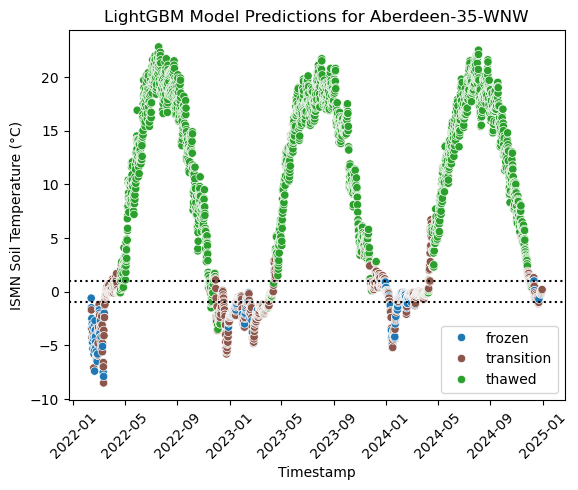

In [13]:
axes = plot_predictions(aberdeen_plot_df, StationName.ABERDEEN, method="lgb_pred")

#### ERA5

In [14]:
formatted_cm(aberdeen_results.y_true, aberdeen_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,452,19,0
transition,349,146,128
thawed,71,70,1957


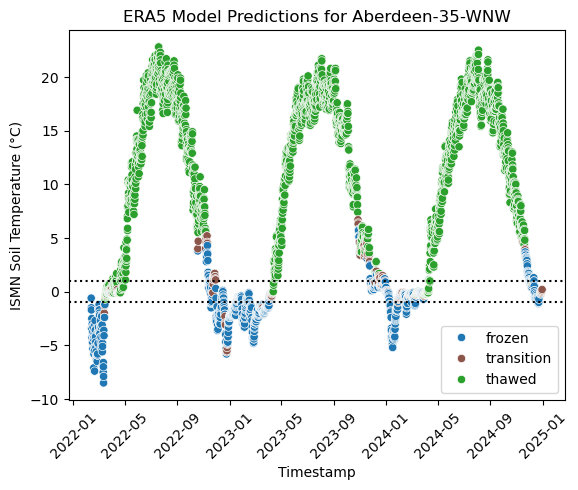

In [16]:
axes = plot_predictions(aberdeen_plot_df, StationName.ABERDEEN, method="era5_pred")

The lightGBM model outperformed in predicting the "transition" state but traded this for inaccurate predictions for the "frozen" state. Both methods had similar predictions for the "thawed" state.

In [15]:
result_df_ascat.loc[len(result_df_ascat)] = [StationName.ABERDEEN,
                                             aberdeen_results.lgb_results.macro_f1,
                                             aberdeen_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.ABERDEEN,
                                           aberdeen_results.era5_results.macro_f1,
                                           aberdeen_results.era5_results.transition_f1]

### 2.2 Jamestown-38-WSW